# Exact-union prediction-pool spatial audit

## TL;DR

This notebook audits whether the legacy `aggregated_mean_fit` pool can represent any exact model variant. It treats unknown Gaia sources as **unlabelled** and reports discrepancy rates and admitted-source densities, not false-positive rates. The canonical numerical evidence is loaded from the persistent expanded-audit outputs; no filtering logic is reimplemented here.

In [1]:
from pathlib import Path
from IPython.display import Image, display
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'configs').exists():
    ROOT = ROOT.parent
RUN_ID = 'audit_20260722_exact_union_spatial_v1'
REPORT_DIR = ROOT / 'reports' / 'analysis' / 'prediction_pool_locus_audit' / RUN_ID
DATA_DIR = ROOT / 'data' / 'processed' / 'prediction_pool_locus_audit' / RUN_ID
assert REPORT_DIR.exists(), f'Run the expanded audit first: {REPORT_DIR}'
print(REPORT_DIR)

E:\Proyectos\Wolf-Rayet-Detector\reports\analysis\prediction_pool_locus_audit\audit_20260722_exact_union_spatial_v1


## Context & Methods

Gaia sources are acquired using only the broad acquisition envelope. The reproducible pipeline then evaluates every exact locus together with its photometric-quality and astrometric conditions. A source is eligible when at least one compatible exact variant accepts it. The legacy aggregate is reconstructed only as the comparator. Each query, Gaia job ID, CSV and SHA-256 is retained in the run manifest.

In [2]:
table_names = [
    'headline_metrics', 'region_summary', 'variant_summary',
    'variant_by_region', 'variant_by_magnitude', 'variant_wr_affected',
    'variant_overlap', 'variant_contract', 'geometric_containment',
    'synthetic_counterexamples', 'magnitude_overall',
    'extinction_summary', 'stratified_summary',
    'known_wr_summary', 'known_wr_affected', 'storage_estimate',
    'legacy_lineage_summary', 'plane_discrepancy_summary',
]
tables = {name: pd.read_csv(REPORT_DIR / f'{name}.csv') for name in table_names}
tables['headline_metrics']

,acquisition_sources,current_aggregate_keep,compatible_exact_union_keep,geometric_exact_not_aggregate,compatible_exact_not_aggregate,aggregate_not_compatible_exact,net_exact_union_growth,envelope_growth
0,44469,24570,26369,1995,1960,161,0.073219,0.80989


## Data

The sky boxes are stratified by Galactic longitude and latitude, observed acquisition density, magnitude, approximate extinction where Gaia GSP-Phot coverage exists, and inner/outer disk. `ag_gspphot` is incomplete and is used descriptively only.

In [3]:
region_columns = [
    'region', 'galactic_l_center', 'galactic_b_center', 'disk_zone',
    'latitude_stratum', 'density_stratum', 'extinction_expectation',
    'ag_gspphot_available_pct', 'ag_gspphot_median', 'acquisition_rows',
    'acquisition_density_per_deg2',
]
tables['region_summary'][region_columns].sort_values('galactic_l_center')

,region,galactic_l_center,galactic_b_center,disk_zone,latitude_stratum,density_stratum,extinction_expectation,ag_gspphot_available_pct,ag_gspphot_median,acquisition_rows,acquisition_density_per_deg2
0,galactic_center_extinction,0.0,0.0,bulge,plane,low,very_high,0.142857,1.93580,21,195.883033
1,inner_plane_l30,29.8,0.4,inner_disk,plane,medium,high,0.497638,4.57075,1270,5085.308555
13,inner_l30_bminus5,30.0,-5.0,inner_disk,low_latitude,high,medium,0.852912,1.41585,6146,12542.935115
12,inner_l30_bplus5,30.0,5.0,inner_disk,low_latitude,high,medium,0.526275,3.46970,5214,10640.882594
2,disk_l60_b0,60.0,0.0,inner_disk,plane,high,high,0.471310,4.82210,2283,9132.017292
3,cygnus_l80,80.6,0.4,inner_disk,plane,medium,high,0.366453,3.94470,936,4989.669602
14,disk_l90_bplus15,90.0,15.0,off_plane,mid_latitude,low,low,0.879203,0.13760,3212,3212.042274
4,outer_l120_b0,120.0,0.0,outer_disk,plane,high,medium,0.756235,1.20510,2125,8500.029170
5,outer_l150_b0,150.0,0.0,outer_disk,plane,medium,medium,0.749869,1.56940,1911,7644.017165
6,anticenter_l180,180.0,0.0,outer_disk,plane,medium,low_to_medium,0.773510,1.05340,6561,7497.016894


## Results — per-variant decision matrix

In [4]:
variant_columns = [
    'variant', 'bit', 'exact_variant_keep', 'exact_variant_not_aggregate',
    'exact_variant_not_aggregate_pct', 'aggregate_not_exact_variant',
    'current_pool_sample_status', 'locus_run_id', 'locus_sha256',
]
display(tables['variant_summary'][variant_columns].sort_values(
    'exact_variant_not_aggregate_pct', ascending=False
))
display(tables['geometric_containment'])
display(tables['synthetic_counterexamples'].groupby('variant').head(2))

,variant,bit,exact_variant_keep,exact_variant_not_aggregate,exact_variant_not_aggregate_pct,aggregate_not_exact_variant,current_pool_sample_status,locus_run_id,locus_sha256
0,strict_photometry,0,20434,1466,0.071743,5602,affected,legacy_exact_strict_photometry_c325b1a02f5c,c325b1a02f5c24563539986dca2c90ad995d0c2411f658...
1,strict_parallax_soft,1,18518,1074,0.057998,7126,affected,legacy_exact_strict_parallax_soft_f25ae9f41a11,f25ae9f41a11135e830cf76eb1522d84ef883284d1a180...
5,relaxed_parallax_soft,9,23168,1287,0.055551,2689,affected,legacy_exact_relaxed_parallax_soft_1dc3db66fad8,1dc3db66fad8ff6a3181d8cb774d500832bc17a30eff8d...
4,relaxed_photometry,8,23929,619,0.025868,1260,affected,legacy_exact_relaxed_photometry_95d32bc1171e,95d32bc1171e97612b81a0aa5e014dd057fba2dfea6fd4...
3,strict_poe_3,4,12716,44,0.003460,11898,affected,legacy_exact_strict_poe_3_08f51ffadcdc,08f51ffadcdc68b5ebea0beb8a5ec30ec98118c06fb2dd...
2,strict_poe_2,3,13248,20,0.001510,11342,affected,legacy_exact_strict_poe_2_971f2b32cb95,971f2b32cb95f89cc69196ec9d4a94dc1fda88549cb778...
7,relaxed_poe_3,12,13427,6,0.000447,11149,affected,legacy_exact_relaxed_poe_3_8d00f4448cdb,8d00f4448cdb87463b53aa87c51c993a589bf1a3c009b0...
6,relaxed_poe_2,11,14594,0,0.000000,9976,no_loss_observed,legacy_exact_relaxed_poe_2_c89831ac114b,c89831ac114b40a28820d578837b9a3d2fe01a2950c47d...


,variant,analytic_contained_planes,analytic_total_planes,analytic_all_planes_contained,minimum_plane_containment_slack,sobol_seed,sobol_power,synthetic_points_inside_color_envelope,synthetic_exact_keep,synthetic_exact_not_aggregate,constructive_counterexample_found,interpretation
0,strict_photometry,0,6,False,-0.076541,20260722,18,258852,70996,4624,True,geometric superset disproved by an envelope-va...
1,strict_parallax_soft,2,6,False,-0.043203,20260722,18,258852,61784,1204,True,geometric superset disproved by an envelope-va...
2,strict_poe_2,4,6,False,-0.016698,20260722,18,258852,46463,254,True,geometric superset disproved by an envelope-va...
3,strict_poe_3,5,6,False,-0.021183,20260722,18,258852,46435,411,True,geometric superset disproved by an envelope-va...
4,relaxed_photometry,0,6,False,-0.040149,20260722,18,258852,72347,3335,True,geometric superset disproved by an envelope-va...
5,relaxed_parallax_soft,2,6,False,-0.015433,20260722,18,258852,64997,870,True,geometric superset disproved by an envelope-va...
6,relaxed_poe_2,4,6,False,-0.022378,20260722,18,258852,43212,25,True,geometric superset disproved by an envelope-va...
7,relaxed_poe_3,3,6,False,-0.032937,20260722,18,258852,42759,462,True,geometric superset disproved by an envelope-va...


,variant,G_BP,G_RP,J_H,H_K,BP_RP,J_K,exact_outlier_plane_count,aggregated_outlier_plane_count,aggregated_boundary_distance,sample_role
0,strict_photometry,-2.778443,0.921279,0.553720,0.404308,3.699723,0.958028,1,2,0.010381,synthetic_geometric_witness_not_gaia_source
1,strict_photometry,-3.654128,1.076368,1.678923,0.782009,4.730495,2.460932,1,2,0.008765,synthetic_geometric_witness_not_gaia_source
20,strict_parallax_soft,-2.967858,1.254658,1.829863,0.712533,4.222516,2.542396,1,2,0.009616,synthetic_geometric_witness_not_gaia_source
21,strict_parallax_soft,-0.481538,0.585875,0.758724,0.268316,1.067414,1.027039,1,2,0.001292,synthetic_geometric_witness_not_gaia_source
40,strict_poe_2,-1.196503,1.154837,1.600745,0.633863,2.351340,2.234608,1,2,0.001861,synthetic_geometric_witness_not_gaia_source
41,strict_poe_2,-2.647090,1.425759,2.050263,0.803127,4.072849,2.853390,1,2,0.006728,synthetic_geometric_witness_not_gaia_source
60,strict_poe_3,-4.209792,1.909361,1.948068,0.752272,6.119154,2.700341,1,2,0.013227,synthetic_geometric_witness_not_gaia_source
61,strict_poe_3,-1.600659,1.279075,2.018832,0.776217,2.879735,2.795048,1,2,0.015045,synthetic_geometric_witness_not_gaia_source
80,relaxed_photometry,-2.778443,0.921279,0.553720,0.404308,3.699723,0.958028,1,2,0.010381,synthetic_geometric_witness_not_gaia_source
81,relaxed_photometry,-4.176759,1.224558,1.319793,0.586967,5.401317,1.906760,1,3,0.005041,synthetic_geometric_witness_not_gaia_source


In [5]:
variant_region = tables['variant_by_region'].pivot(
    index='variant', columns='region', values='exact_variant_not_aggregate_pct'
)
variant_region.style.format('{:.2%}', na_rep='—').background_gradient(cmap='magma', axis=None)

region,anticenter_l180,cygnus_l80,disk_l270_b0,disk_l270_bminus15,disk_l60_b0,disk_l90_bplus15,galactic_center_extinction,inner_l300_b0,inner_l30_bminus5,inner_l30_bplus5,inner_l330_b0,inner_plane_l30,legacy_high_latitude,outer_l120_b0,outer_l150_b0,outer_l180_bplus30,outer_l210_b0,outer_l240_b0
variant,,,,,,,,,,,,,,,,,,
relaxed_parallax_soft,2.70%,4.89%,7.53%,2.15%,14.48%,1.60%,11.11%,13.39%,6.89%,12.89%,13.28%,13.17%,3.03%,3.78%,2.46%,2.01%,1.62%,2.67%
relaxed_photometry,0.15%,3.48%,5.22%,0.16%,8.79%,0.16%,0.00%,9.17%,0.52%,6.12%,7.84%,8.64%,0.00%,0.83%,0.09%,0.00%,0.09%,0.10%
relaxed_poe_2,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
relaxed_poe_3,0.08%,0.00%,0.00%,0.06%,0.00%,0.06%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.14%,0.09%,0.00%,0.00%
strict_parallax_soft,1.82%,4.73%,8.40%,1.11%,18.02%,0.64%,0.00%,14.75%,4.04%,15.13%,15.93%,15.82%,0.00%,3.12%,2.09%,0.72%,0.73%,1.18%
strict_photometry,1.51%,5.78%,10.97%,0.36%,19.88%,0.36%,0.00%,18.28%,3.89%,17.06%,15.13%,17.24%,0.00%,3.35%,1.40%,0.31%,0.48%,0.78%
strict_poe_2,0.00%,0.91%,0.50%,0.00%,1.24%,0.00%,0.00%,0.85%,0.00%,0.00%,1.65%,0.99%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
strict_poe_3,0.00%,1.38%,1.00%,0.00%,2.98%,0.00%,0.00%,2.17%,0.00%,1.13%,2.34%,3.33%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%


### Spatial, magnitude and extinction diagnostics

In [6]:
summary_columns = [
    'region', 'acquisition_rows', 'aggregated_keep', 'any_exact_variant_keep',
    'exact_variant_not_aggregate', 'exact_variant_not_aggregate_pct_exact_union',
    'aggregate_not_exact_variant', 'density_stratum', 'ag_gspphot_stratum',
]
tables['region_summary'][summary_columns].sort_values(
    'exact_variant_not_aggregate_pct_exact_union', ascending=False
)

,region,acquisition_rows,aggregated_keep,any_exact_variant_keep,exact_variant_not_aggregate,exact_variant_not_aggregate_pct_exact_union,aggregate_not_exact_variant,density_stratum,ag_gspphot_stratum
2,disk_l60_b0,2283,1168,1439,272,0.189020,1,high,high
10,inner_l300_b0,2173,1067,1297,231,0.178103,1,high,high
1,inner_plane_l30,1270,721,871,150,0.172216,0,medium,high
12,inner_l30_bplus5,5214,2193,2604,412,0.158218,1,high,high
11,inner_l330_b0,1142,768,896,130,0.145089,2,low,high
0,galactic_center_extinction,21,8,9,1,0.111111,0,low,high
9,disk_l270_b0,1998,1275,1428,155,0.108543,2,high,high
13,inner_l30_bminus5,6146,2096,2231,159,0.071268,24,high,medium
3,cygnus_l80,936,651,691,44,0.063676,4,medium,high
4,outer_l120_b0,2125,1275,1320,59,0.044697,14,high,medium


In [7]:
display(tables['magnitude_overall'])
display(tables['extinction_summary'])
display(tables['stratified_summary'].sort_values(
    'exact_variant_not_aggregate_pct_exact_union', ascending=False
))

,magnitude_bin,acquisition_rows,aggregated_keep,any_exact_variant_keep,exact_variant_not_aggregate,exact_variant_not_aggregate_pct,exact_variant_not_aggregate_pct_exact_union
0,G<12,596,283,292,12,0.020134,0.041096
1,12<=G<14,2792,1478,1546,80,0.028653,0.051746
2,14<=G<16,10035,5675,5909,317,0.031589,0.053647
3,16<=G<18,18662,10179,10830,702,0.037617,0.064820
4,G>=18,12384,6955,7792,849,0.068556,0.108958


,ag_gspphot_bin,acquisition_rows,aggregated_keep,any_exact_variant_keep,exact_variant_not_aggregate,aggregate_not_exact_variant,exact_variant_not_aggregate_pct_exact_union,coverage_note
0,missing,12887,6843,7692,877,28,0.114015,Gaia GSP-Phot proxy unavailable
1,1.5<ag<=3,6691,3155,3317,173,11,0.052156,descriptive G-band extinction proxy; not a label
2,ag>3,5675,2611,3255,644,0,0.197849,descriptive G-band extinction proxy; not a label
3,0.5<ag<=1.5,10392,6220,6337,176,59,0.027773,descriptive G-band extinction proxy; not a label
4,ag<=0.5,8824,5741,5768,90,63,0.015603,descriptive G-band extinction proxy; not a label


,dimension,stratum,region_count,acquisition_rows,aggregated_keep,any_exact_variant_keep,exact_variant_not_aggregate,exact_variant_not_aggregate_pct_exact_union,aggregate_not_exact_variant
14,expected_extinction,high,5,7804,4375,5194,827,0.159222,8
1,disk_zone,inner_disk,7,19164,8664,10029,1398,0.139396,33
12,density,high,6,19939,9074,10319,1288,0.124818,43
6,latitude,low_latitude,2,11360,4289,4835,571,0.118097,25
0,disk_zone,bulge,1,21,8,9,1,0.111111,0
13,expected_extinction,very_high,1,21,8,9,1,0.111111,0
3,disk_zone,disk_transition,1,1998,1275,1428,155,0.108543,2
15,expected_extinction,medium,6,19027,9110,9900,848,0.085657,58
5,latitude,plane,12,23826,14694,15871,1255,0.079075,78
11,density,medium,6,14084,9133,9482,407,0.042923,58


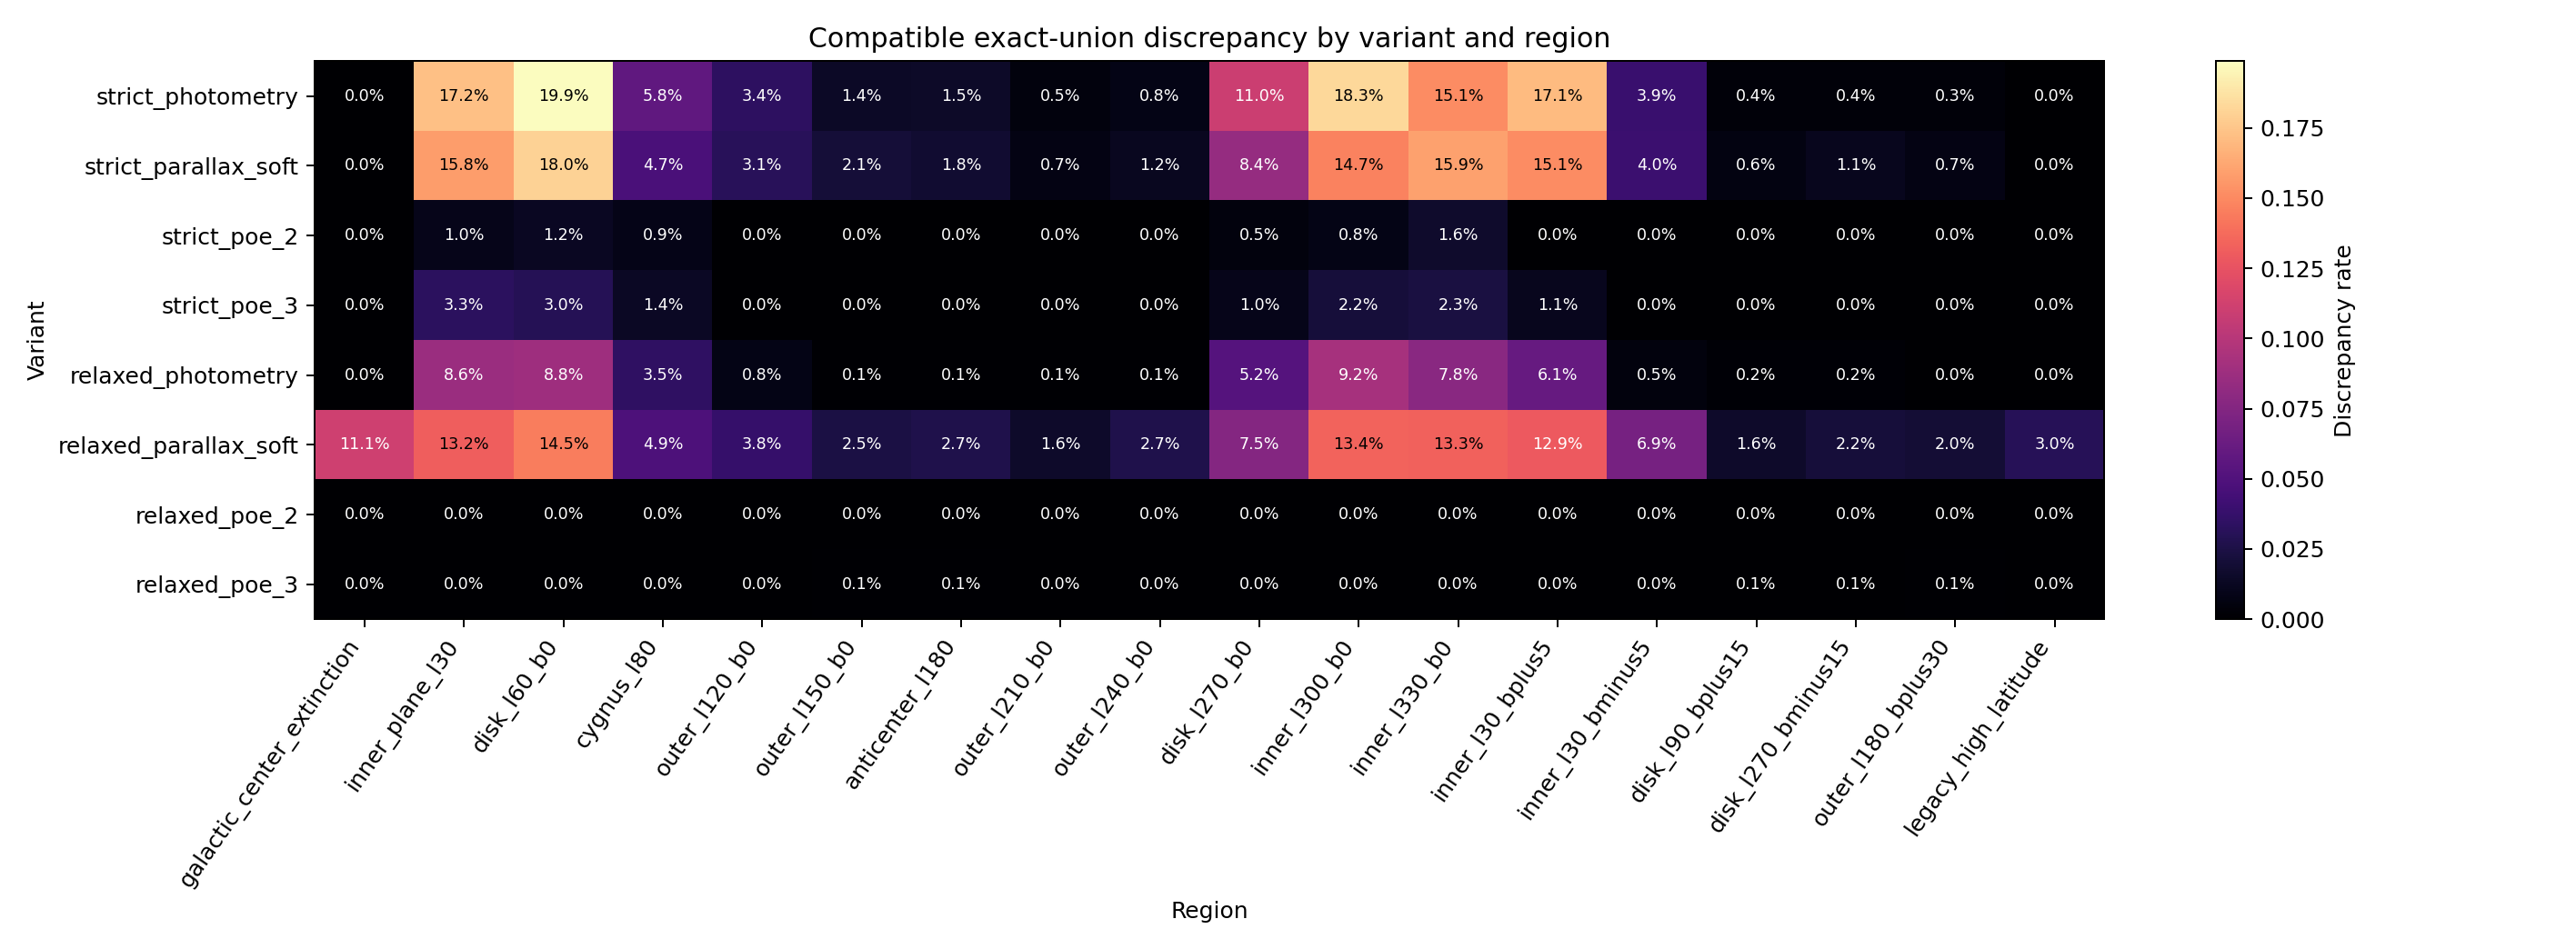

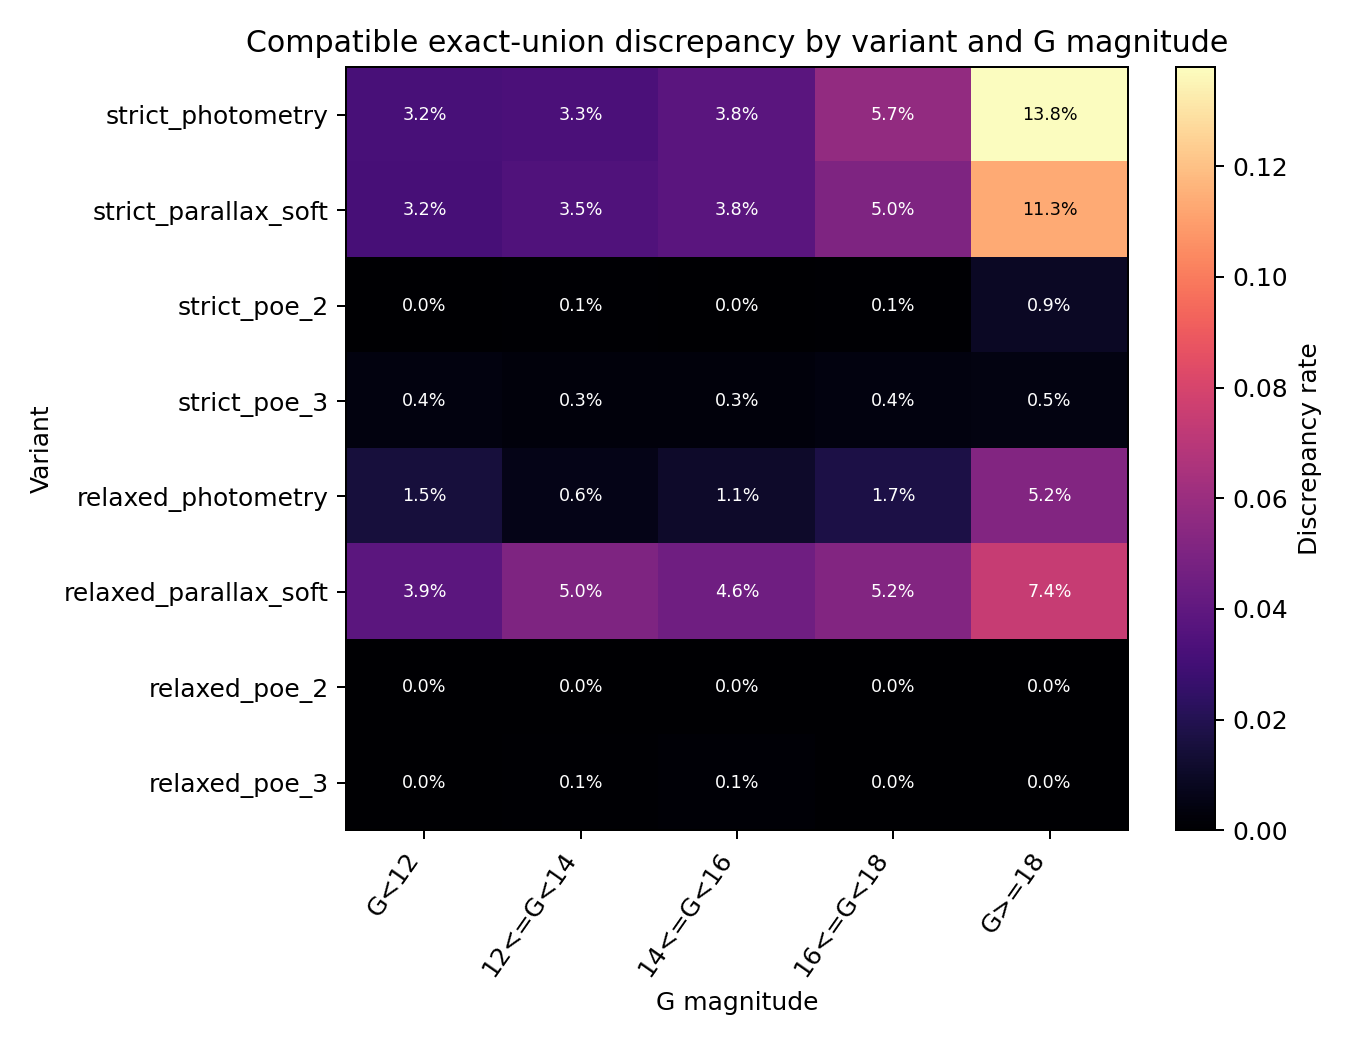

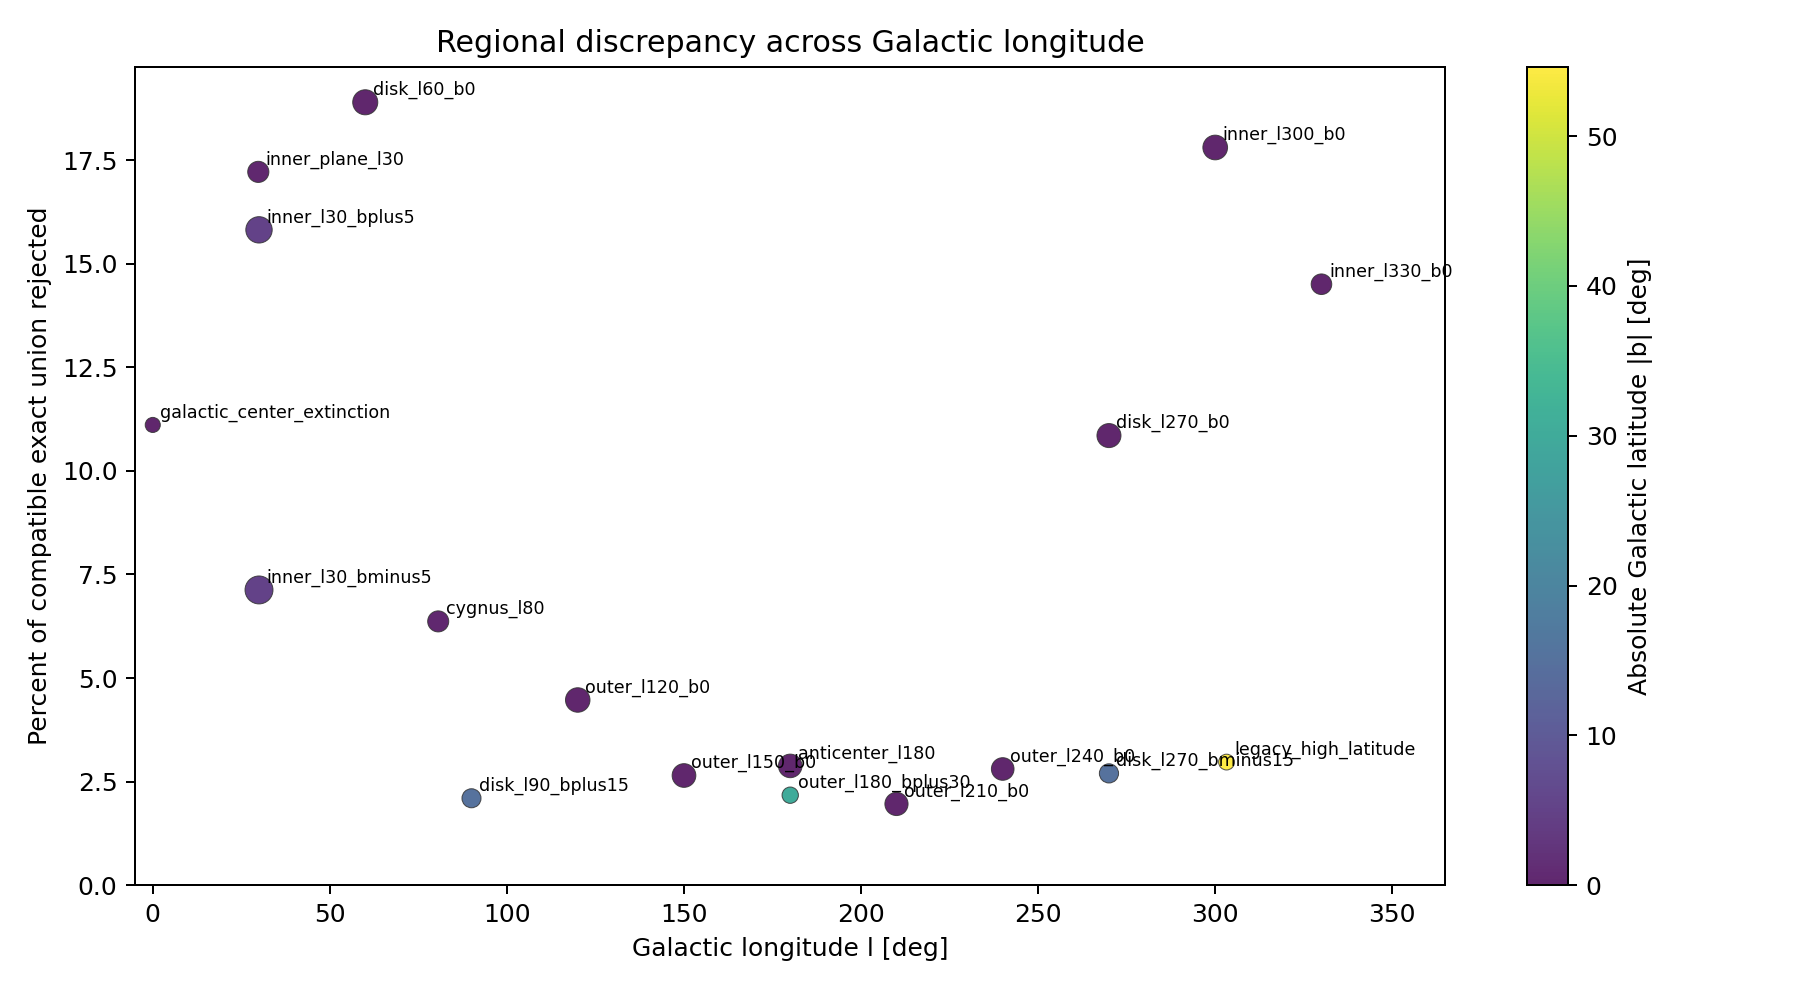

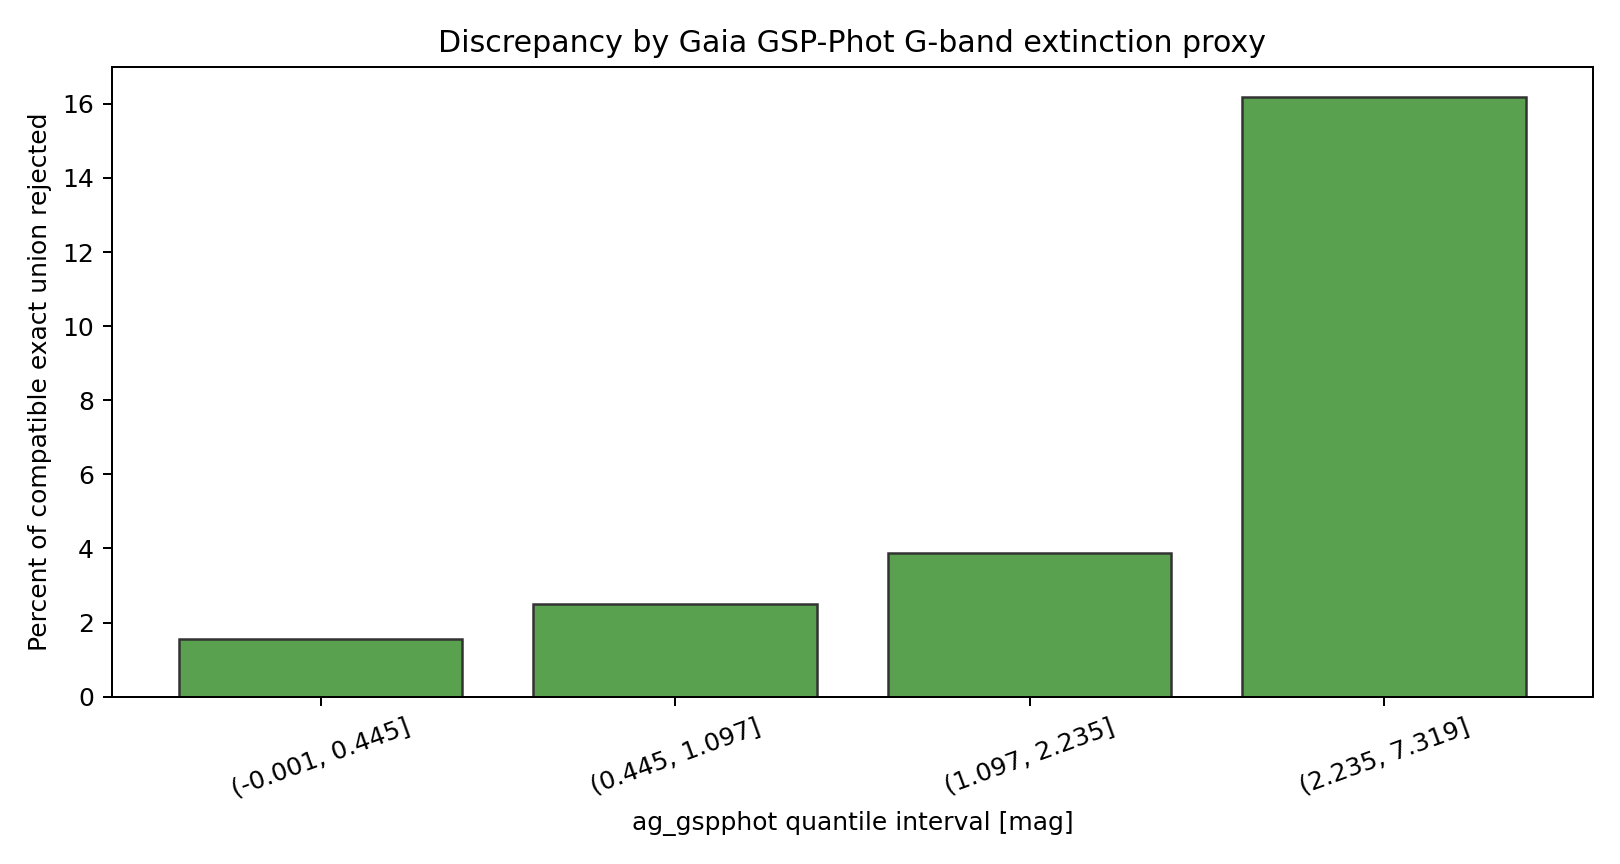

In [8]:
figure_names = [
    'variant_by_region_loss_heatmap.png',
    'variant_by_magnitude_loss_heatmap.png',
    'spatial_discrepancy_by_galactic_longitude.png',
    'discrepancy_by_ag_gspphot.png',
]
for name in figure_names:
    path = REPORT_DIR / name
    if path.exists():
        display(Image(filename=str(path), width=1000))

### Variant overlap and known-WR regression controls

In [9]:
overlap = tables['variant_overlap'].pivot(
    index='left_variant', columns='right_variant', values='jaccard'
)
display(overlap.style.format('{:.1%}', na_rep='—').background_gradient(cmap='viridis', axis=None))
display(tables['variant_wr_affected'])

right_variant,relaxed_parallax_soft,relaxed_photometry,relaxed_poe_2,relaxed_poe_3,strict_parallax_soft,strict_photometry,strict_poe_2,strict_poe_3
left_variant,,,,,,,,
relaxed_parallax_soft,100.0%,83.2%,62.8%,57.5%,78.3%,69.9%,57.2%,54.0%
relaxed_photometry,83.2%,100.0%,58.5%,53.2%,69.2%,76.6%,53.5%,49.5%
relaxed_poe_2,62.8%,58.5%,100.0%,89.3%,54.0%,48.8%,71.9%,67.2%
relaxed_poe_3,57.5%,53.2%,89.3%,100.0%,51.3%,46.1%,69.0%,73.6%
strict_parallax_soft,78.3%,69.2%,54.0%,51.3%,100.0%,86.6%,70.2%,65.0%
strict_photometry,69.9%,76.6%,48.8%,46.1%,86.6%,100.0%,62.0%,57.3%
strict_poe_2,57.2%,53.5%,71.9%,69.0%,70.2%,62.0%,100.0%,87.2%
strict_poe_3,54.0%,49.5%,67.2%,73.6%,65.0%,57.3%,87.2%,100.0%


,variant,bit,source_id,wr_id,Spectral Type,G,aggregated_outlier_plane_count
0,strict_photometry,0,4306688266055108480,122-15,WN6,18.465389,2
1,strict_photometry,0,2013906561629759232,157,WN5o(+B1II),10.346903,3
2,strict_parallax_soft,1,4306688266055108480,122-15,WN6,18.465389,2


## Storage and lineage

The estimates below are measured from Zstandard Parquet samples and scaled using the observed legacy pool. They compare eligible-only storage, two physical layers, and acquisition-with-mask plus logical views.

In [10]:
display(tables['storage_estimate'][[
    'scenario', 'primary_rows', 'secondary_rows', 'estimated_gib', 'basis'
]])
display(tables['variant_contract'])
display(tables['legacy_lineage_summary'])

,scenario,primary_rows,secondary_rows,estimated_gib,basis
0,legacy_aggregate_actual,58037788,0,10.086440,observed current pool parquet inventory
1,eligible_only,62287278,0,14.766119,expanded-audit exact/aggregate ratio and eligi...
2,acquisition_plus_eligible,105042019,62287278,38.476955,two physical parquet layers measured on expand...
3,acquisition_with_mask_logical_views,105042019,0,23.881745,one acquisition parquet layer plus uint64 mask...


,variant,bit,bit_value,bitmask_schema_version,bitmask_schema_sha256,locus_run_id,locus_sha256,photometric_condition,astrometric_condition,required_colors
0,strict_photometry,0,1,compatible_variant_mask_v1_803a87c65e99,803a87c65e999566f3a8bb50041807feb8d8899ce3043d...,legacy_exact_strict_photometry_c325b1a02f5c,c325b1a02f5c24563539986dca2c90ad995d0c2411f658...,2MASS J/H/Ks and WISE W1/W2 quality A,no parallax condition,"BP_RP,G_BP,G_RP,H_K,J_H,J_K"
1,strict_parallax_soft,1,2,compatible_variant_mask_v1_803a87c65e99,803a87c65e999566f3a8bb50041807feb8d8899ce3043d...,legacy_exact_strict_parallax_soft_f25ae9f41a11,f25ae9f41a11135e830cf76eb1522d84ef883284d1a180...,2MASS J/H/Ks and WISE W1/W2 quality A,parallax > 0,"BP_RP,G_BP,G_RP,H_K,J_H,J_K"
2,strict_poe_2,3,8,compatible_variant_mask_v1_803a87c65e99,803a87c65e999566f3a8bb50041807feb8d8899ce3043d...,legacy_exact_strict_poe_2_971f2b32cb95,971f2b32cb95f89cc69196ec9d4a94dc1fda88549cb778...,2MASS J/H/Ks and WISE W1/W2 quality A,parallax > 0 and parallax_over_error >= 2,"BP_RP,G_BP,G_RP,H_K,J_H,J_K"
3,strict_poe_3,4,16,compatible_variant_mask_v1_803a87c65e99,803a87c65e999566f3a8bb50041807feb8d8899ce3043d...,legacy_exact_strict_poe_3_08f51ffadcdc,08f51ffadcdc68b5ebea0beb8a5ec30ec98118c06fb2dd...,2MASS J/H/Ks and WISE W1/W2 quality A,parallax > 0 and parallax_over_error >= 3,"BP_RP,G_BP,G_RP,H_K,J_H,J_K"
4,relaxed_photometry,8,256,compatible_variant_mask_v1_803a87c65e99,803a87c65e999566f3a8bb50041807feb8d8899ce3043d...,legacy_exact_relaxed_photometry_95d32bc1171e,95d32bc1171e97612b81a0aa5e014dd057fba2dfea6fd4...,2MASS J/H/Ks and WISE W1/W2 quality A or B,no parallax condition,"BP_RP,G_BP,G_RP,H_K,J_H,J_K"
5,relaxed_parallax_soft,9,512,compatible_variant_mask_v1_803a87c65e99,803a87c65e999566f3a8bb50041807feb8d8899ce3043d...,legacy_exact_relaxed_parallax_soft_1dc3db66fad8,1dc3db66fad8ff6a3181d8cb774d500832bc17a30eff8d...,2MASS J/H/Ks and WISE W1/W2 quality A or B,parallax > 0,"BP_RP,G_BP,G_RP,H_K,J_H,J_K"
6,relaxed_poe_2,11,2048,compatible_variant_mask_v1_803a87c65e99,803a87c65e999566f3a8bb50041807feb8d8899ce3043d...,legacy_exact_relaxed_poe_2_c89831ac114b,c89831ac114b40a28820d578837b9a3d2fe01a2950c47d...,2MASS J/H/Ks and WISE W1/W2 quality A or B,parallax > 0 and parallax_over_error >= 2,"BP_RP,G_BP,G_RP,H_K,J_H,J_K"
7,relaxed_poe_3,12,4096,compatible_variant_mask_v1_803a87c65e99,803a87c65e999566f3a8bb50041807feb8d8899ce3043d...,legacy_exact_relaxed_poe_3_8d00f4448cdb,8d00f4448cdb87463b53aa87c51c993a589bf1a3c009b0...,2MASS J/H/Ks and WISE W1/W2 quality A or B,parallax > 0 and parallax_over_error >= 3,"BP_RP,G_BP,G_RP,H_K,J_H,J_K"


,csv_count,csv_bytes,partial_registry_matches,partial_completed_matches,partial_registry_orphan_count,partial_registry_orphans,main_registry_matches,config_hash_available,acquisition_envelope_hash_available,exact_locus_hash_available,query_text_or_hash_available,primary_analysis_eligible,reason
0,386,2504583862,385,385,1,test_simple,0,False,False,False,False,False,Tile/job/timestamp lineage exists for 385 CSVs...


## Limitations & robustness

This is a deliberately stratified audit, not a probability sample of the sky. Regional rates should identify systematic regimes but must not be multiplied directly by 58 million. GSP-Phot extinction coverage and accuracy are limited, especially on difficult/high-extinction sightlines. Known WR controls are regression checks because the reference population contributed to locus construction.

## Takeaways

The operational decision is to build a new exact-union pool in parallel and preserve the current `aggregated_mean_fit` pool as a read-only legacy artifact. A single immutable acquisition Parquet layer with a versioned compatibility mask and logical eligible/model views minimizes re-query risk and physical duplication. Definitive scoring remains blocked until the new pool passes manifest, count, checksum, resume and model-bit validation.